In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [3]:
df = pd.read_sql_query(
    '''
    SELECT 
        uid,
        timestamp,
        numTrials
    FROM checker
    WHERE 
        uid LIKE 'user_%'
        AND status = 'ready'
        AND labname = 'project1'
    ''',
    conn,
    parse_dates=['timestamp'],
)

print(df.shape)
df = df.sort_values('uid')
df

(951, 3)


,uid,timestamp,numTrials
926,user_1,2020-05-14 21:21:00.651643,8
907,user_1,2020-05-14 21:12:49.812670,6
886,user_1,2020-05-14 20:56:08.898880,1
888,user_1,2020-05-14 20:58:46.322457,3
928,user_1,2020-05-14 21:23:00.570667,9
...,...,...,...
747,user_8,2020-05-14 15:50:51.715993,2
905,user_8,2020-05-14 21:12:17.314337,8
762,user_8,2020-05-14 16:11:00.491523,3
833,user_8,2020-05-14 17:40:47.781946,6


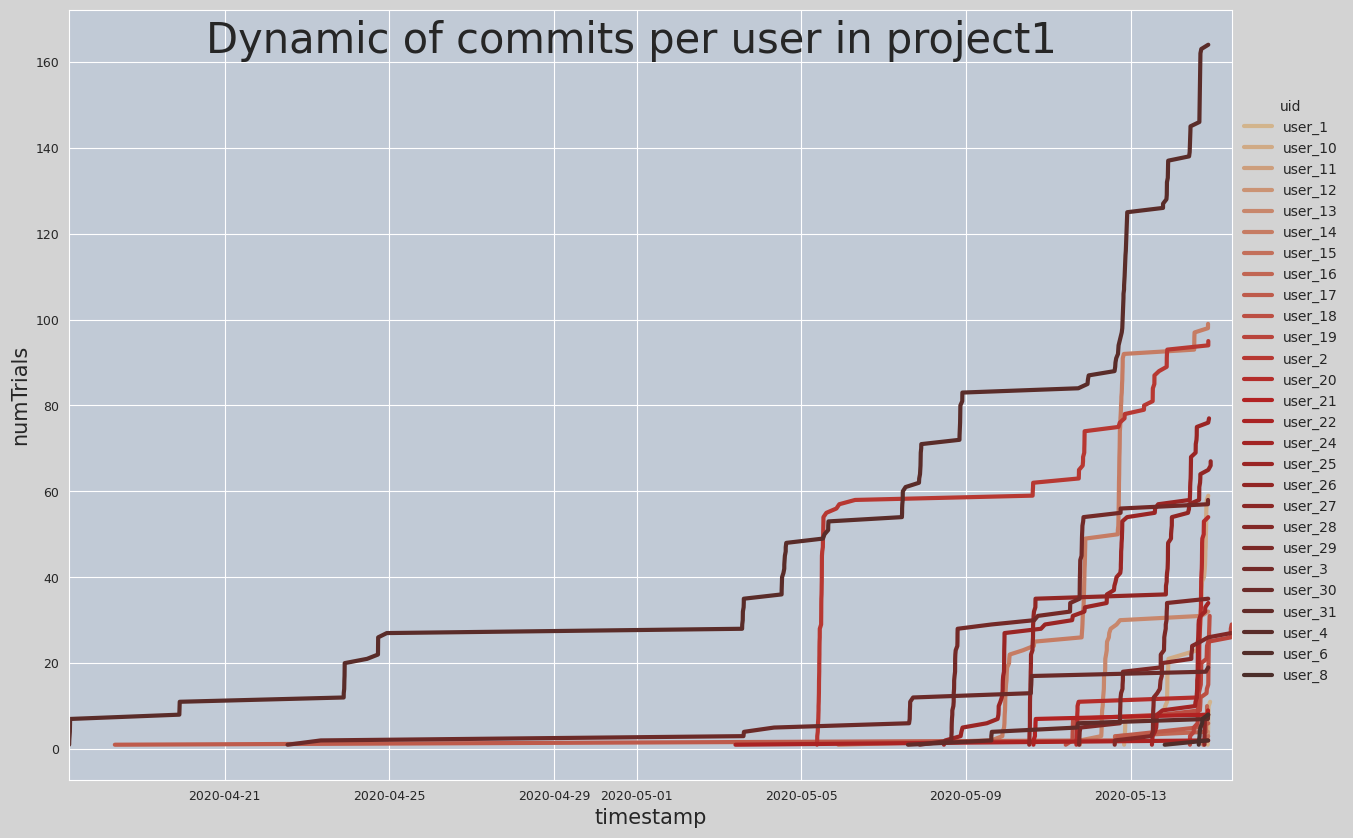

In [4]:
from matplotlib.colors import LinearSegmentedColormap
colors = ["#D2B48C", "#B22222", "#4B2E2A"]
custom_cmap = LinearSegmentedColormap.from_list("brown_gradient", colors)

uids = df['uid'].unique()
n_users = len(uids)
color_list = [custom_cmap(i / (n_users - 1)) for i in range(n_users)]

height, aspect = 10, 1.5
width = height * aspect

plt.figure(figsize=(width, height))
fig = plt.gcf()
fig.patch.set_facecolor('lightgray')
sns.set_style("darkgrid", {'axes.facecolor': '#C1CAD6'})
sns.lineplot(
    data=df,
    x='timestamp',
    y='numTrials',
    hue='uid',
    palette=color_list,
    linewidth=3,
    sort=True,
)
plt.legend(bbox_to_anchor=(1, 0.9), )
legend = plt.gca().get_legend()
legend.get_frame().set_facecolor('lightgray')
legend.get_frame().set_linewidth(0)
legend.set_title("uid")
plt.grid(True)
plt.suptitle('Dynamic of commits per user in project1', fontsize=30, y= 0.87)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.xlabel('timestamp',fontsize=15)
plt.ylabel('numTrials',fontsize=15)
plt.xlim(df['timestamp'].min(), df['timestamp'].max())
plt.show()


- Which user was the leader in the number of commits almost all of the time? User_4  
- Which user was the leader for only a short period of time? User_2

In [5]:
conn.close()